# Amazon Product Data Analysis

---

# Import Required Libraries

In [1]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text Processing
from textblob import TextBlob

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)

# Style
sns.set(style='whitegrid')

# Load Dataset

In [2]:
df = pd.read_csv("amazon.csv")

df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [3]:
# Basic Info
print("Shape of Dataset:", df.shape)
print("\nColumns:\n", df.columns)
print("\nData Types:\n")
print(df.dtypes)

Shape of Dataset: (1465, 16)

Columns:
 Index(['product_id', 'product_name', 'category', 'discounted_price',
       'actual_price', 'discount_percentage', 'rating', 'rating_count',
       'about_product', 'user_id', 'user_name', 'review_id', 'review_title',
       'review_content', 'img_link', 'product_link'],
      dtype='object')

Data Types:

product_id             object
product_name           object
category               object
discounted_price       object
actual_price           object
discount_percentage    object
rating                 object
rating_count           object
about_product          object
user_id                object
user_name              object
review_id              object
review_title           object
review_content         object
img_link               object
product_link           object
dtype: object


# Missing Values Check

In [4]:
df.isnull().sum()

,0
product_id,0
product_name,0
category,0
discounted_price,0
actual_price,0
discount_percentage,0
rating,0
rating_count,2
about_product,0
user_id,0


# Duplicate Rows Check

In [5]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


# Data Cleaning (Prices)

In [6]:
# Remove ₹ and commas
df['discounted_price'] = df['discounted_price'].str.replace('₹', '').str.replace(',', '').astype(float)
df['actual_price'] = df['actual_price'].str.replace('₹', '').str.replace(',', '').astype(float)

# Clean percentage
df['discount_percentage'] = df['discount_percentage'].str.replace('%', '').astype(float)

# Convert rating
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
df['rating_count'] = df['rating_count'].str.replace(',', '').fillna(0).astype(float)

Converts price columns into numbers for analysis.

# Final Missing Values Handling

In [7]:
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print("New Shape:", df.shape)

New Shape: (1464, 16)


In [8]:
df.describe()

,discounted_price,actual_price,discount_percentage,rating,rating_count
count,1464.000000,1464.000000,1464.000000,1464.000000,1464.000000
mean,3126.011906,5447.002923,47.713115,4.096585,18282.366803
std,6946.625442,10878.270001,21.627422,0.291674,42742.207636
min,39.000000,39.000000,0.000000,2.000000,0.000000
25%,323.750000,800.000000,32.000000,4.000000,1179.000000
50%,799.000000,1650.000000,50.000000,4.100000,5178.500000
75%,1999.000000,4303.750000,63.000000,4.300000,17330.750000
max,77990.000000,139900.000000,94.000000,5.000000,426973.000000


# Exploratory Data Analysis

---



# Top Categories by Product Count

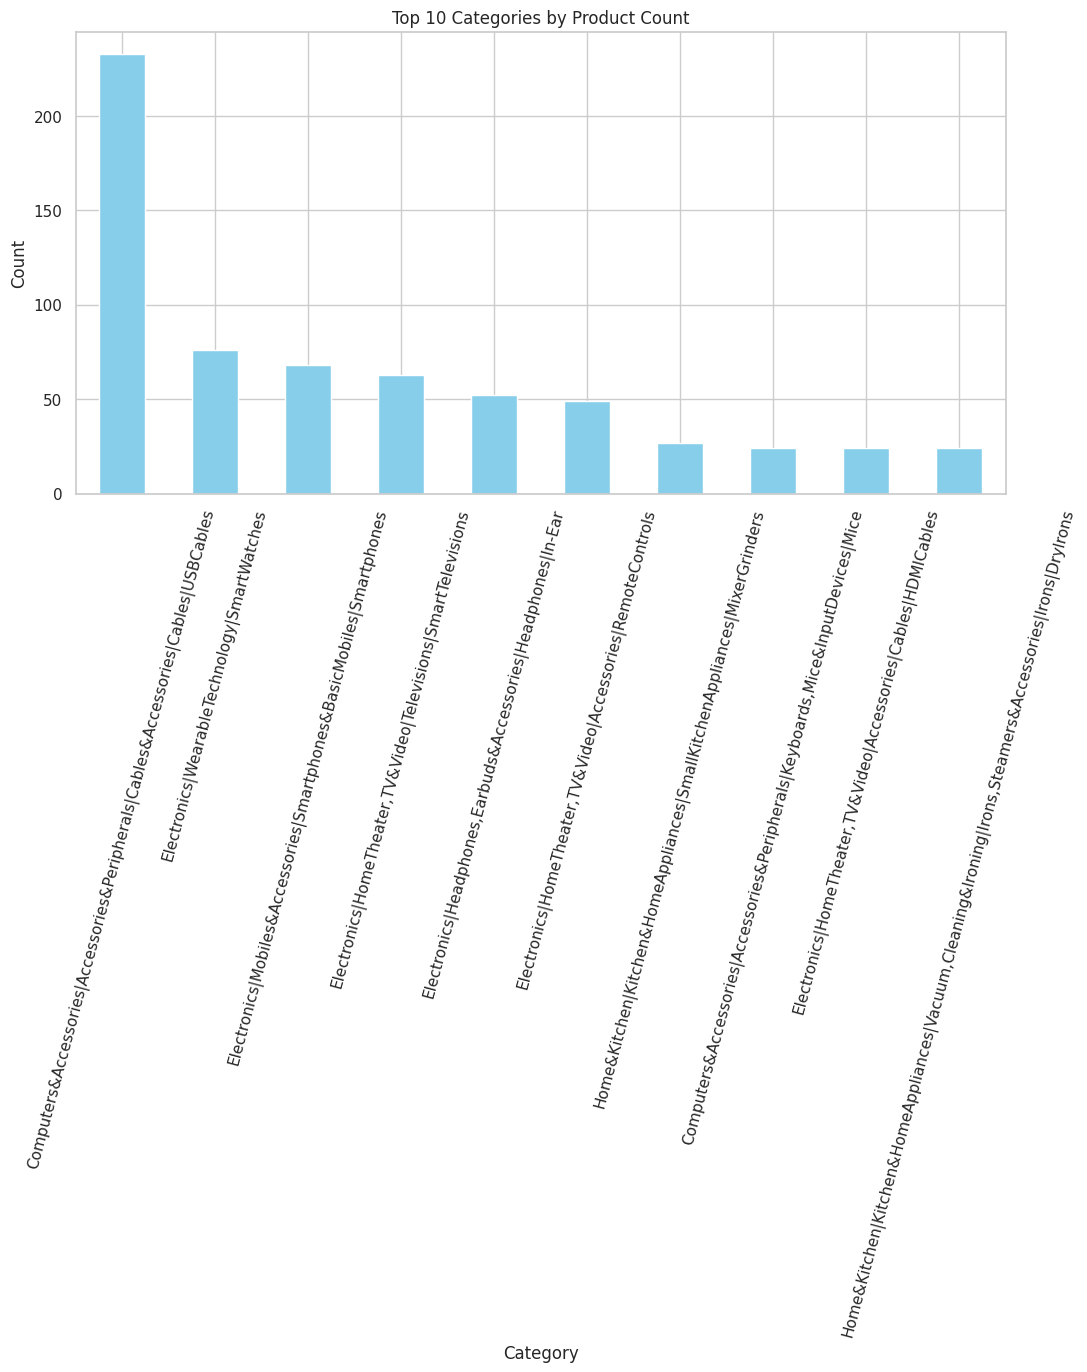

In [9]:
plt.figure(figsize=(12,6))
df['category'].value_counts().head(10).plot(kind='bar', color='skyblue')
plt.title("Top 10 Categories by Product Count")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=75)
plt.show()

# Price Distribution

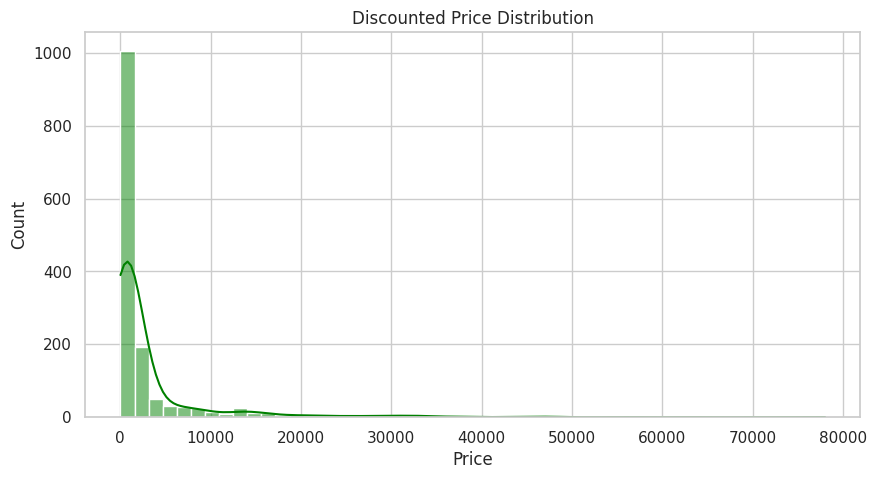

In [10]:
plt.figure(figsize=(10,5))
sns.histplot(df['discounted_price'], bins=50, kde=True, color='green')
plt.title("Discounted Price Distribution")
plt.xlabel("Price")
plt.show()

# Actual Price vs Discounted Price

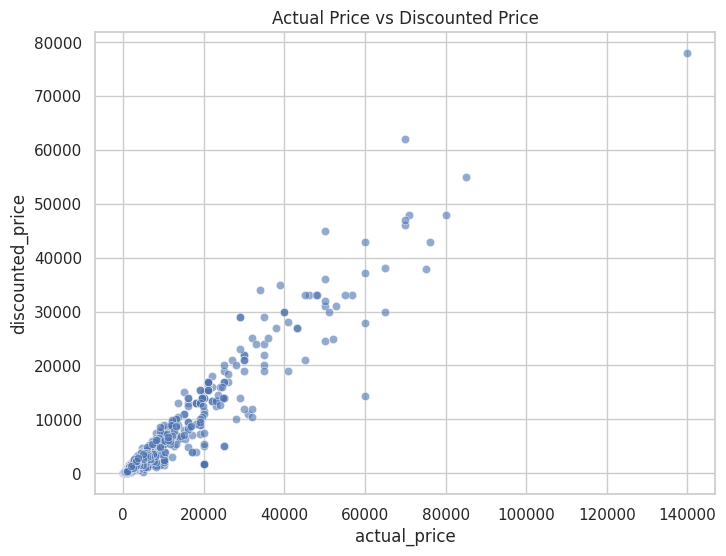

In [11]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='actual_price', y='discounted_price', data=df, alpha=0.6)
plt.title("Actual Price vs Discounted Price")
plt.show()

# Highest Discount Products

In [12]:
top_discount = df[['product_name', 'discount_percentage']].sort_values(by='discount_percentage', ascending=False).head(10)
top_discount

,product_name,discount_percentage
695,"rts [2 Pack] Mini USB C Type C Adapter Plug, T...",94.0
334,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",91.0
368,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",91.0
364,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",91.0
372,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",91.0
380,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",91.0
602,LAPSTER Spiral Charger Spiral Charger Cable Pr...,90.0
1026,beatXP Kitchen Scale Multipurpose Portable Ele...,90.0
644,Sounce Spiral Charger Cable Protector Data Cab...,90.0
557,LAPSTER 12pcs Spiral Cable Protectors for Char...,90.0


# Ratings Distribution

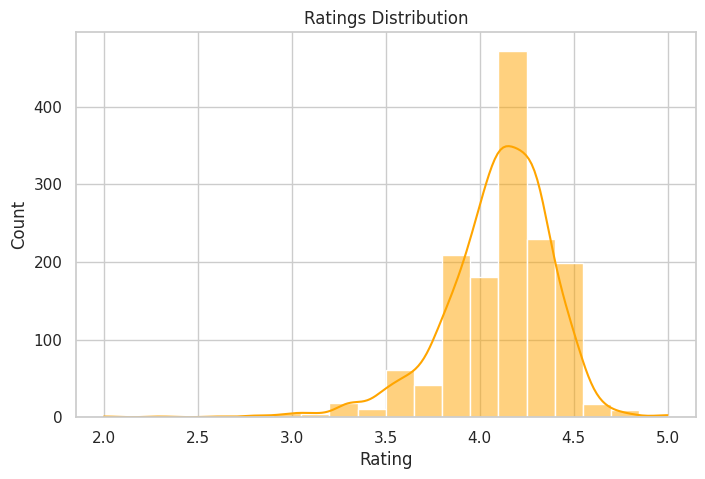

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df['rating'], bins=20, kde=True, color='orange')
plt.title("Ratings Distribution")
plt.xlabel("Rating")
plt.show()

# Rating vs Discount

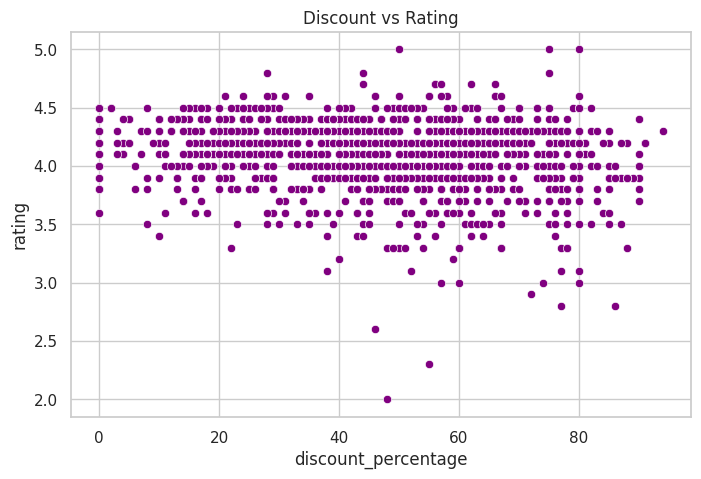

In [14]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='discount_percentage', y='rating', data=df, color='purple')
plt.title("Discount vs Rating")
plt.show()

# Most Reviewed Products

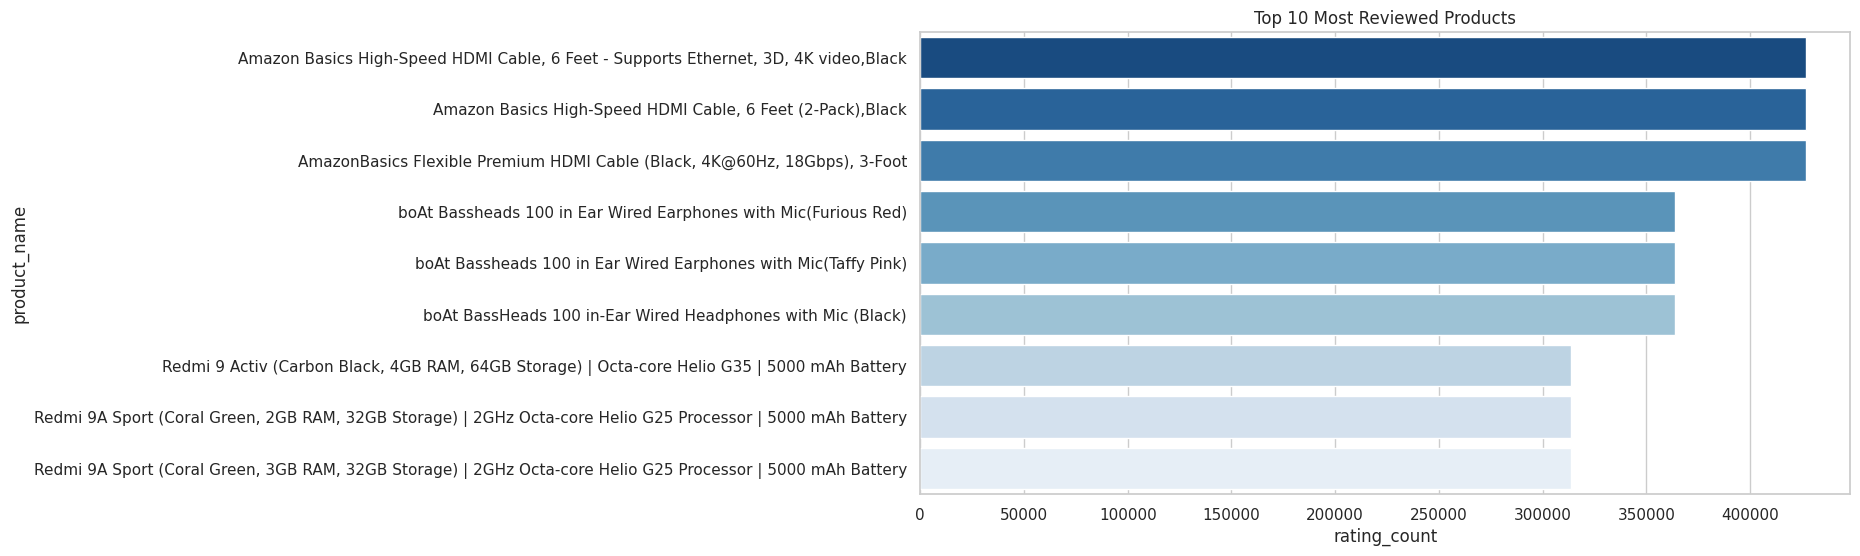

In [15]:
top_reviewed = df[['product_name', 'rating_count']].sort_values(by='rating_count', ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x='rating_count', y='product_name', data=top_reviewed, palette='Blues_r')
plt.title("Top 10 Most Reviewed Products")
plt.show()

# Top Rated Products (Reliable)

In [16]:
best_products = df[(df['rating'] >= 4.5) & (df['rating_count'] >= 1000)]
best_products[['product_name', 'rating', 'rating_count']].head(10)

,product_name,rating,rating_count
30,AmazonBasics USB 2.0 - A-Male to A-Female Exte...,4.5,74976.0
40,AmazonBasics USB 2.0 Cable - A-Male to B-Male ...,4.5,107687.0
98,TP-Link UE300 USB 3.0 to RJ45 Gigabit Ethernet...,4.5,22420.0
137,"10k 8k 4k HDMI Cable, Certified 48Gbps 1ms Ult...",4.6,3664.0
146,AmazonBasics New Release Nylon USB-A to Lightn...,4.5,5492.0
212,AmazonBasics USB 2.0 Extension Cable for Perso...,4.5,74977.0
249,Sony Bravia 164 cm (65 inches) 4K Ultra HD Sma...,4.7,5935.0
291,AmazonBasics 10.2 Gbps High-Speed 4K HDMI Cabl...,4.5,1029.0
431,Goldmedal Curve Plus 202042 Plastic Spice 3-Pi...,4.5,11339.0
447,Spigen EZ Fit Tempered Glass Screen Protector ...,4.6,26603.0


# Best Value Score

In [17]:
df['value_score'] = (df['rating'] * df['discount_percentage']) / df['discounted_price']

best_value = df[['product_name', 'value_score']].sort_values(by='value_score', ascending=False).head(10)
best_value

,product_name,value_score
645,GIZGA essentials Universal Silicone Keyboard P...,7.807692
178,FLiX (Beetel Flow USB to Micro USB PVC Data Sy...,4.905856
798,"Gizga Essentials Webcam Cover, Privacy Protect...",4.798551
478,Flix Micro Usb Cable For Smartphone (Black),4.745763
23,Flix Micro Usb Cable For Smartphone (Black),4.745763
44,FLiX (Beetel USB to Micro USB PVC Data Sync & ...,4.745763
727,Flix Micro Usb Cable For Smartphone (Black),4.745763
521,STRIFF 12 Pieces Highly Flexible Silicone Micr...,4.465823
488,Elv Mobile Phone Mount Tabletop Holder for Pho...,4.106742
557,LAPSTER 12pcs Spiral Cable Protectors for Char...,4.000000


Products with high ratings + high discounts + low price.

# Correlation Heatmap

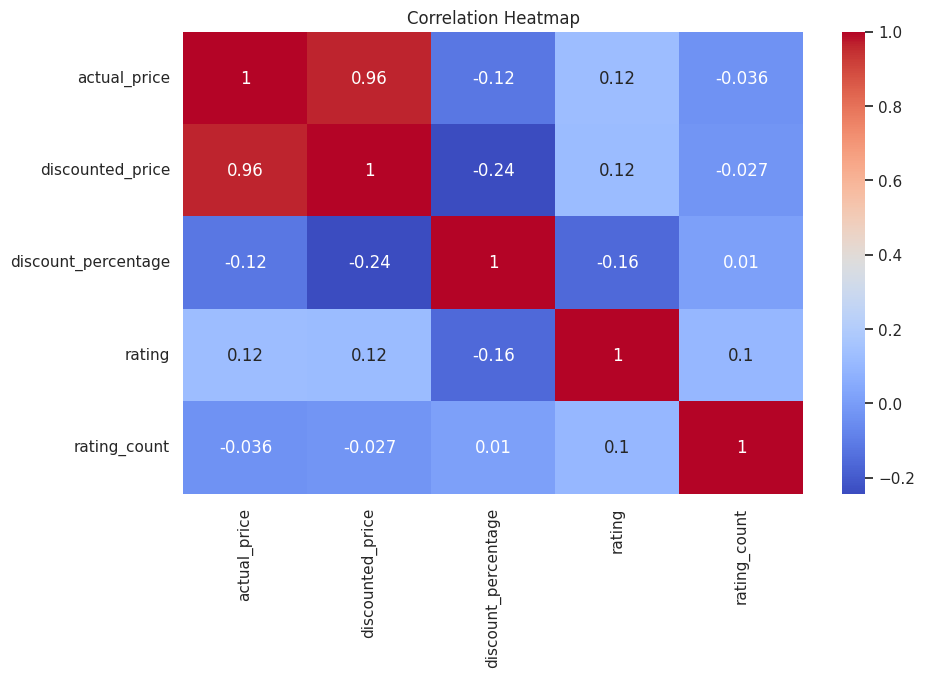

In [18]:
plt.figure(figsize=(10,6))
sns.heatmap(df[['actual_price', 'discounted_price', 'discount_percentage', 'rating', 'rating_count']].corr(),
            annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# **Sentiment Analysis**

---



In [19]:
#Review Sentiment Function

def get_sentiment(text):
    score = TextBlob(str(text)).sentiment.polarity

    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

In [20]:
# Apply Sentiment
df['sentiment'] = df['review_content'].apply(get_sentiment)
df['sentiment'].value_counts()

,count
sentiment,
Positive,1437
Negative,26
Neutral,1


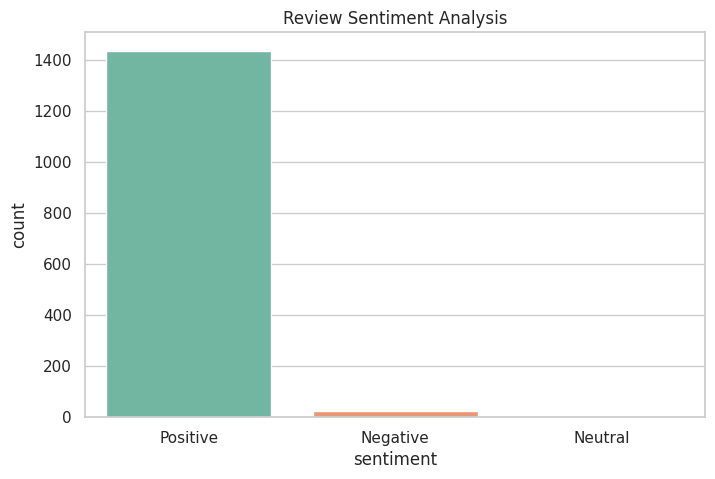

In [21]:
# Sentiment Visualization
plt.figure(figsize=(8,5))
sns.countplot(x='sentiment', data=df, palette='Set2')
plt.title("Review Sentiment Analysis")
plt.show()

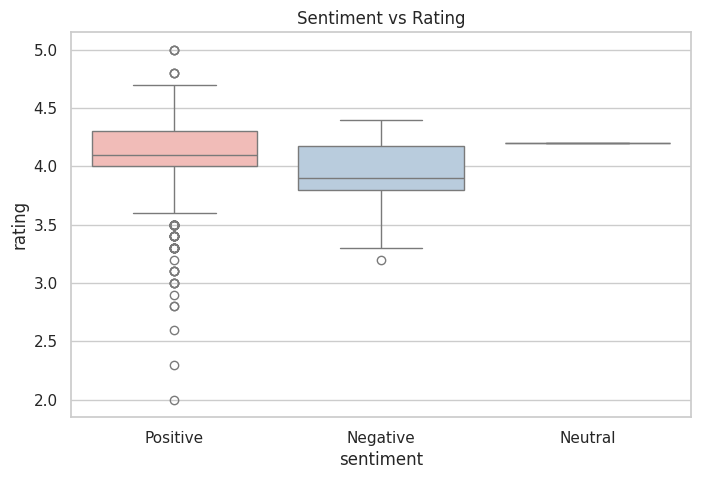

In [22]:
# Sentiment vs Rating

plt.figure(figsize=(8,5))
sns.boxplot(x='sentiment', y='rating', data=df, palette='Pastel1')
plt.title("Sentiment vs Rating")
plt.show()

## Key Findings

In [23]:
print("Average Product Rating:", round(df['rating'].mean(),2))
print("Average Discount %:", round(df['discount_percentage'].mean(),2))
print("Average Price:", round(df['discounted_price'].mean(),2))
print("Most Common Sentiment:", df['sentiment'].mode()[0])

Average Product Rating: 4.1
Average Discount %: 47.71
Average Price: 3126.01
Most Common Sentiment: Positive


# Final Conclusion

---



In [24]:
print("""
Project Conclusion:

1. Electronics categories dominate the dataset.
2. Most products are rated above 4 stars.
3. High discounts attract attention but don't guarantee high ratings.
4. Positive sentiment dominates customer reviews.
5. Some affordable products provide excellent value.

This analysis helps businesses optimize pricing, product quality, and marketing strategy.
""")


Project Conclusion:

1. Electronics categories dominate the dataset.
2. Most products are rated above 4 stars.
3. High discounts attract attention but don't guarantee high ratings.
4. Positive sentiment dominates customer reviews.
5. Some affordable products provide excellent value.

This analysis helps businesses optimize pricing, product quality, and marketing strategy.

